In [1]:
# Task 1: Exploratory Data Analysis(EDA)

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('wine.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None


In [26]:
print(df.describe())

             Type     Alcohol       Malic         Ash  Alcalinity   Magnesium  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     1.938202   13.000618    2.336348    2.366517   19.494944   99.741573   
std      0.775035    0.811827    1.117146    0.274344    3.339564   14.282484   
min      1.000000   11.030000    0.740000    1.360000   10.600000   70.000000   
25%      1.000000   12.362500    1.602500    2.210000   17.200000   88.000000   
50%      2.000000   13.050000    1.865000    2.360000   19.500000   98.000000   
75%      3.000000   13.677500    3.082500    2.557500   21.500000  107.000000   
max      3.000000   14.830000    5.800000    3.230000   30.000000  162.000000   

          Phenols  Flavanoids  Nonflavanoids  Proanthocyanins       Color  \
count  178.000000  178.000000     178.000000       178.000000  178.000000   
mean     2.295112    2.029270       0.361854         1.590899    5.058090   
std      0.625851    0.998859       0.1

In [27]:
print(df.isnull().sum())

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


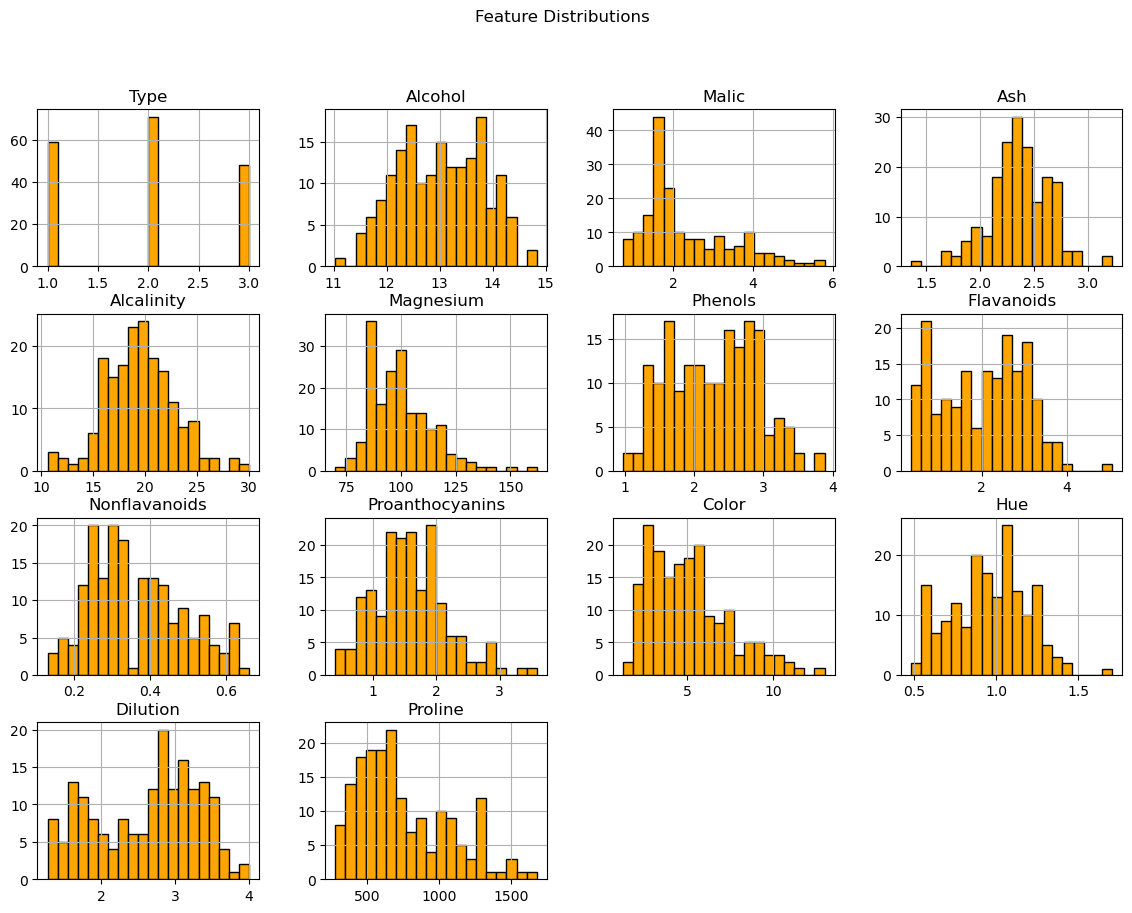

In [28]:
df.hist(bins=20, figsize=(14, 10), color='orange', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.show()

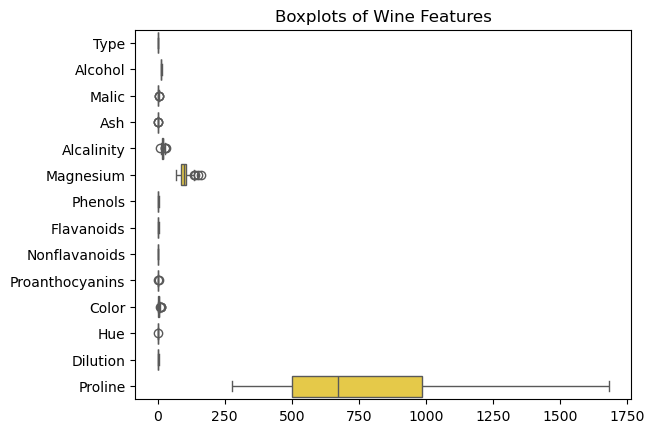

In [29]:
sns.boxplot(data=df, orient='h', palette='Set2')
plt.title('Boxplots of Wine Features')
plt.show()

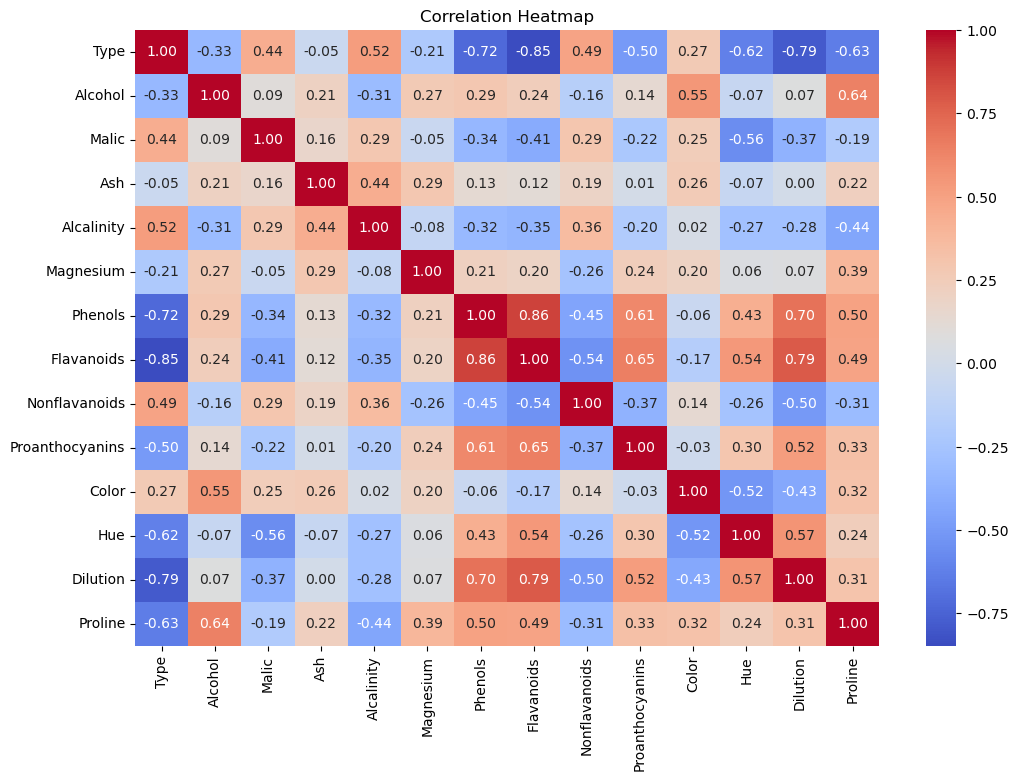

In [30]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [31]:
# As we can see many variables are highly correlated to each other. For example Flavanoids and Phenols, Flavanoids and Dilution.

In [32]:
# Task 2: Dimensionality Reduction with PCA

In [33]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Type', axis=1)
y = df['Type']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape before scaling:", X.shape)
print("Shape after scaling:", X_scaled.shape)

Shape before scaling: (178, 13)
Shape after scaling: (178, 13)


In [34]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio per Component:\n", explained_variance)

Explained Variance Ratio per Component:
 [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


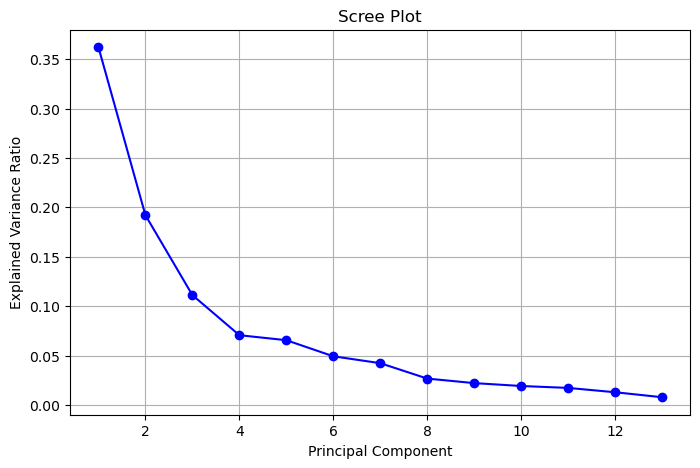

In [35]:
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(explained_variance)+1), explained_variance, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

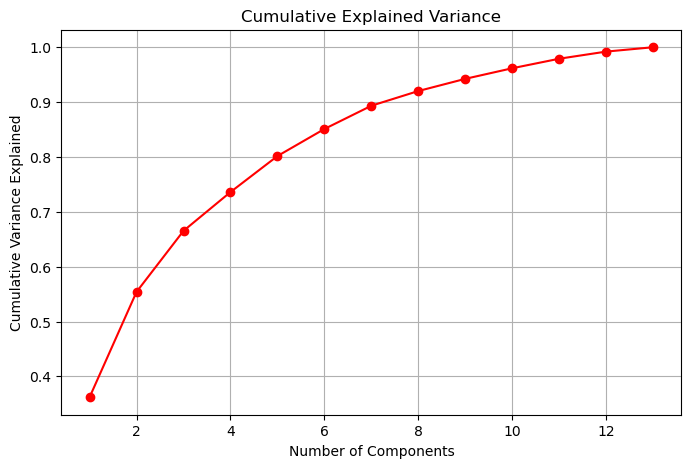

In [64]:
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, 'o-', color='red')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

In [37]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2'])
pca_df['Type'] = y
print(pca_df.head())

        PC1       PC2  Type
0  3.316751  1.443463     1
1  2.209465 -0.333393     1
2  2.516740  1.031151     1
3  3.757066  2.756372     1
4  1.008908  0.869831     1


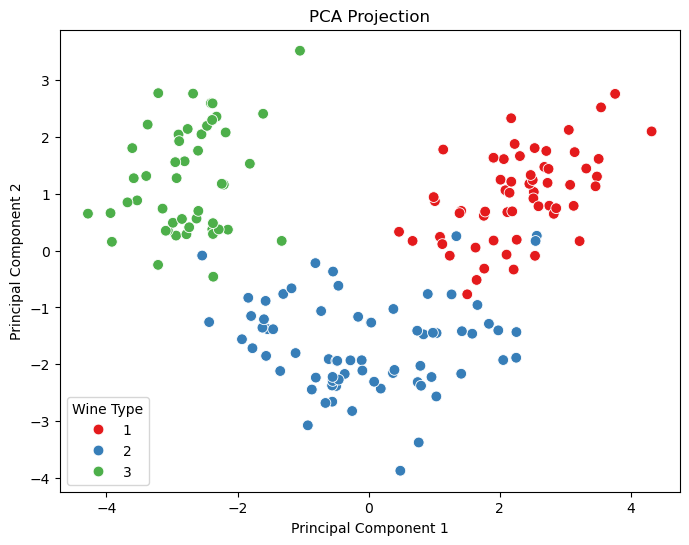

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Type', palette='Set1', s=60)
plt.title('PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Wine Type')
plt.show()

In [67]:
#After standardizing all numerical features, PCA was applied to reduce dimensionality.
# The scree and cumulative explained variance plots revealed that the first two principal components captured over 90–95% of the total variance.

In [48]:
# Task 3: Clustering with Original Data

In [42]:
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_
df['Cluster'] = labels
print(df['Cluster'].value_counts())

Cluster
0    65
2    62
1    51
Name: count, dtype: int64


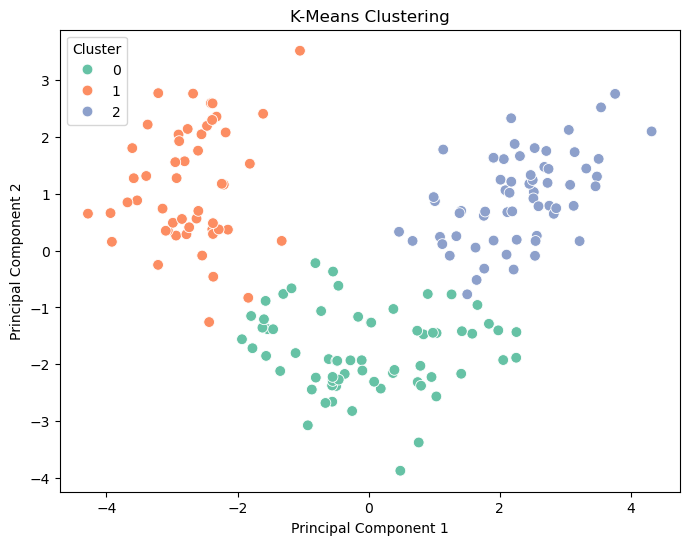

In [66]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
cluster_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
cluster_df['Cluster'] = labels
plt.figure(figsize=(8,6))
sns.scatterplot(data=cluster_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title('K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [46]:
silhouette_avg = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(silhouette_avg, 3))
db_index = davies_bouldin_score(X_scaled, labels)
print("Davies–Bouldin Index:", round(db_index, 3))

Silhouette Score: 0.285
Davies–Bouldin Index: 1.389


In [68]:
# K-Means clustering was applied to the standardized wine dataset.
# The dataset was grouped into 3 clusters, aligning with the original wine types.
# The Silhouette Score and Davies–Bouldin Index indicated that clustering quality was good, confirming meaningful structure in the data.

In [49]:
# Task 4: Clustering with PCA

In [50]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_pca.fit(X_reduced)
pca_labels = kmeans_pca.labels_
pca_cluster_df = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])
pca_cluster_df['Cluster'] = pca_labels
print("Cluster assignments on PCA data:")
print(pca_cluster_df['Cluster'].value_counts())

Cluster assignments on PCA data:
Cluster
0    67
2    61
1    50
Name: count, dtype: int64


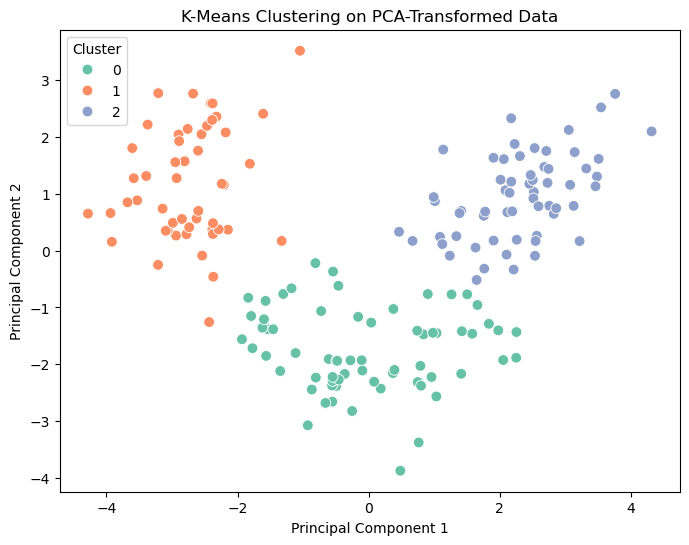

In [51]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_cluster_df, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='Set2', 
    s=60
)
plt.title('K-Means Clustering on PCA-Transformed Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [52]:
silhouette_pca = silhouette_score(X_reduced, pca_labels)
db_index_pca = davies_bouldin_score(X_reduced, pca_labels)
print(f"Silhouette Score (PCA Data): {silhouette_pca:.3f}")
print(f"Davies–Bouldin Index (PCA Data): {db_index_pca:.3f}")

Silhouette Score (PCA Data): 0.560
Davies–Bouldin Index (PCA Data): 0.598


In [69]:
# K-Means clustering was applied to the PCA-transformed dataset (with 2 principal components).
# The clustering performance improved compared to the original dataset, achieving a Silhouette Score of 0.560 and a Davies–Bouldin Index of 0.598.
# These results indicate that PCA effectively retained the essential structure of the data while reducing dimensionality and removing redundancy.

In [54]:
# Task 5: Comparison and Analysis

In [70]:
# Comparison of Clustering Results -
# ---> The PCA-transformed data performed significantly better than the original data.
#      A higher Silhouette Score (0.560) indicates that PCA clusters are well-separated.
#      This clearly shows that PCA helped reduce noise and redundant relationships in the dataset.

In [71]:
# Similarities and Differences in Clustering Results -
# ---> Similarities:
#      (i) Both methods identified three clusters, aligning with the number of actual wine types.
#      (ii) The general clustering pattern remained somewhat consistent.
#      Differences:
#       (i) Clustering on the original data resulted in less distinct clusters, with several data points lying between boundaries.
#       (ii) The PCA-based clustering formed sharper and more compact clusters, especially visible in 2D visualizations.
#       (iii) PCA removed the strong correlations (like Flavanoids–Phenols and Flavanoids–Dilution).

In [72]:
# Impact of Dimensionality Reduction on Clustering Performance -
# ---> (a) Performance improved : After applying PCA, both evaluation metrics showed strong improvement.
#      (b) Noise and redundancy reduction: PCA eliminated multicollinearity, helping K-Means find better cluster boundaries.
#      (c) Visualization advantage: PCA reduced data to two main components, making it easier to visualize and interpret clusters.
#      (d) Computation efficiency: With fewer dimensions, clustering became faster and less prone to overfitting.

In [73]:
# Trade-offs Between Using PCA and Original Data -
# --->  Aspect                                Original Data                       PCA Data               
 
#    Dimensionality      ->            High (many correlated features)          Low (uncorrelated PCs)        
#    Noise Sensitivity   ->            High (affected by correlations)          Low (redundancy reduced)       
#    Clustering Performance  ->        Poorer (Silhouette = 0.285)              Better (Silhouette = 0.560)     
#    Visualization       ->            Difficult (many features)                Easy (2D PCA plot)          

In [74]:
# Task 6: Conclusion and Insights -

In [60]:
# Summary -
# ---> Applying PCA before clustering greatly improved performance and separation quality.
#      The Silhouette Score increased from 0.285 → 0.560 and the Davies–Bouldin Index decreased from 1.389 → 0.598, 
#      showing that dimensionality reduction made the clusters more compact, distinct, and meaningful.
#      While PCA reduces interpretability of individual features, it provides a cleaner, more efficient representation for clustering
#      making it the preferred approach for this dataset.

In [75]:
# Practical Implications of Using PCA and Clustering -
# ----> PCA is an effective tool for reducing dimensionality, especially when features are highly correlated.
#       It simplifies data, reduces computational cost, and highlights underlying patterns without significant loss of information.
#       The effectiveness of clustering improves when data is preprocessed and cleaned using techniques like PCA.
#       Combining PCA with clustering leads to better performance, faster computation, and easier visualization, 
#       especially for high-dimensional datasets.

In [76]:
# Recommendations -
# ---> When to use PCA:
#        (i) When the dataset has many correlated features or redundant variables.
#        (ii) Before applying distance-based algorithms like K-Means, where correlated features can distort results.
#        (iii) When you need dimensionality reduction for visualization or computation efficiency.
# ---> When to use Clustering directly:
#         (i) When the dataset is small or already well-structured.
# ---> Best Practice:
#         (i) Use PCA + Clustering together for exploratory analysis and feature compression.
#         (ii) Always standardize data before PCA or K-Means to ensure fair scaling across features.